In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Fraud Detection Workflow

This notebook loads, cleans, explores, and models transaction data to evaluate whether the available features can distinguish fraudulent transactions.

## Load and Inspect Data

Load the transaction file, inspect dimensions and data types, and standardize column names and categorical values.

In [2]:
df = pd.read_csv('fraud_data.csv')
df.shape

(51000, 12)

In [3]:
df.head(3)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0


In [4]:
df.dtypes

Transaction_ID                          str
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                        str
Time_of_Transaction                 float64
Device_Used                             str
Location                                str
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                          str
Fraudulent                            int64
dtype: object

In [5]:
df.columns = df.columns.str.lower()
df.columns.to_list()

['transaction_id',
 'user_id',
 'transaction_amount',
 'transaction_type',
 'time_of_transaction',
 'device_used',
 'location',
 'previous_fraudulent_transactions',
 'account_age',
 'number_of_transactions_last_24h',
 'payment_method',
 'fraudulent']

In [6]:
for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df.head()

,transaction_id,user_id,transaction_amount,transaction_type,time_of_transaction,device_used,location,previous_fraudulent_transactions,account_age,number_of_transactions_last_24h,payment_method,fraudulent
0,t1,4174,1292.76,atm_withdrawal,16.0,tablet,san_francisco,0,119,13,debit_card,0
1,t2,4507,1554.58,atm_withdrawal,13.0,mobile,new_york,4,79,3,credit_card,0
2,t3,1860,2395.02,atm_withdrawal,NaN,mobile,NaN,3,115,9,NaN,0
3,t4,2294,100.10,bill_payment,15.0,desktop,chicago,4,3,4,upi,0
4,t5,2130,1490.50,pos_payment,19.0,mobile,san_francisco,2,57,7,credit_card,0


## Clean and Validate Data

Remove duplicates and identifier columns, inspect missing values, and verify the target distribution before modeling.

In [7]:
df.isnull().sum()

transaction_id                         0
user_id                                0
transaction_amount                  2520
transaction_type                       0
time_of_transaction                 2552
device_used                         2473
location                            2547
previous_fraudulent_transactions       0
account_age                            0
number_of_transactions_last_24h        0
payment_method                      2469
fraudulent                             0
dtype: int64

In [8]:
df.describe().round(2)

,user_id,transaction_amount,time_of_transaction,previous_fraudulent_transactions,account_age,number_of_transactions_last_24h,fraudulent
count,51000.00,48480.00,48448.00,51000.00,51000.00,51000.00,51000.00
mean,3005.11,2996.25,11.49,2.00,60.03,7.50,0.05
std,1153.12,5043.93,6.92,1.42,34.38,4.02,0.22
min,1000.00,5.03,0.00,0.00,1.00,1.00,0.00
25%,2007.00,1270.55,5.00,1.00,30.00,4.00,0.00
50%,2996.00,2524.10,12.00,2.00,60.00,7.00,0.00
75%,4006.00,3787.24,17.00,3.00,90.00,11.00,0.00
max,4999.00,49997.80,23.00,4.00,119.00,14.00,1.00


In [9]:
df.user_id.nunique(), df.transaction_id.nunique()

(4000, 50000)

In [10]:
df.duplicated().sum()

np.int64(881)

In [11]:
df=df.drop_duplicates()
df.shape

(50119, 12)

In [12]:
df = df.drop(columns=['transaction_id', 'user_id'])

In [13]:
df.fraudulent.value_counts()

fraudulent
0    47652
1     2467
Name: count, dtype: int64

In [14]:
df.fraudulent.value_counts(normalize=True)*100

fraudulent
0    95.077715
1     4.922285
Name: proportion, dtype: float64

In [15]:
cat_cols = df.select_dtypes(include=['object','string']).columns.to_list()
num_cols = df.select_dtypes(include=['int64','float64']).columns.to_list()
num_cols.remove('fraudulent')
    

    


In [16]:
df[cat_cols] = df[cat_cols].fillna('Unknown')


In [17]:
df.isnull().sum()

transaction_amount                  2476
transaction_type                       0
time_of_transaction                 2505
device_used                            0
location                               0
previous_fraudulent_transactions       0
account_age                            0
number_of_transactions_last_24h        0
payment_method                         0
fraudulent                             0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

Examine class imbalance, numerical distributions, categorical distributions, correlations, and potential outliers.

In [19]:
df[num_cols].describe().round(2)

,transaction_amount,time_of_transaction,previous_fraudulent_transactions,account_age,number_of_transactions_last_24h
count,47643.00,47614.00,50119.00,50119.00,50119.00
mean,2999.10,11.49,2.00,60.03,7.50
std,5061.21,6.92,1.42,34.39,4.02
min,5.03,0.00,0.00,1.00,1.00
25%,1269.83,5.00,1.00,30.00,4.00
50%,2523.58,12.00,2.00,60.00,7.00
75%,3785.09,17.00,3.00,90.00,11.00
max,49997.80,23.00,4.00,119.00,14.00


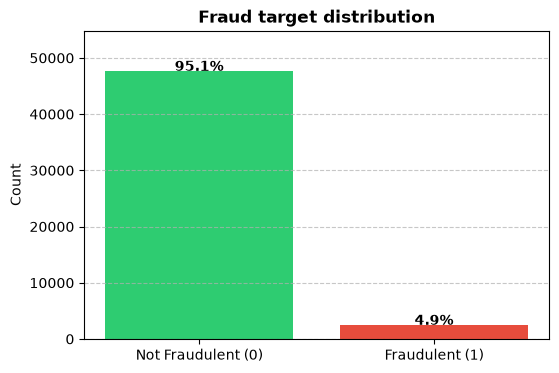

In [20]:
fraud_counts = df.fraudulent.value_counts().sort_index()   # 0 first, then 1
fraud_pct = df.fraudulent.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(['Not Fraudulent (0)', 'Fraudulent (1)'], fraud_counts.values, color=['#2ecc71', '#e74c3c'])
plt.title('Fraud target distribution', fontweight='bold')
plt.ylabel('Count')
for bar, pct in zip(bars, fraud_pct.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f'{pct:.1f}%', ha='center', fontweight='bold')
plt.ylim(0, fraud_counts.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observation: The dataset is highly imbalanced, with fraudulent transactions making up approximately 5% of the data.

### Numerical Feature Distributions

Compare numerical feature distributions overall and by fraud label. Transaction amount is strongly right-skewed, so a log transformation is considered later.

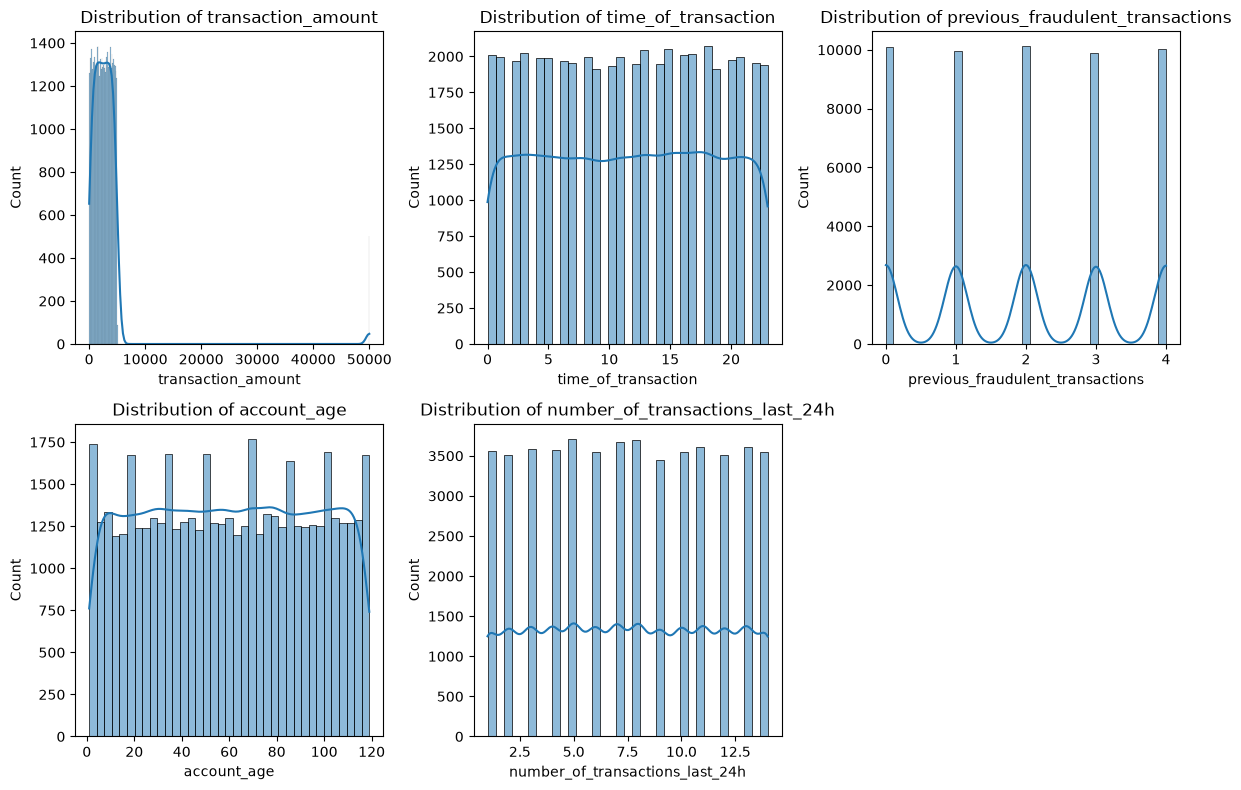

In [21]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Hide unused plots
for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

 Observation: Most numerical features are reasonably distributed, while transaction_amount shows a strong right-skewed distribution.

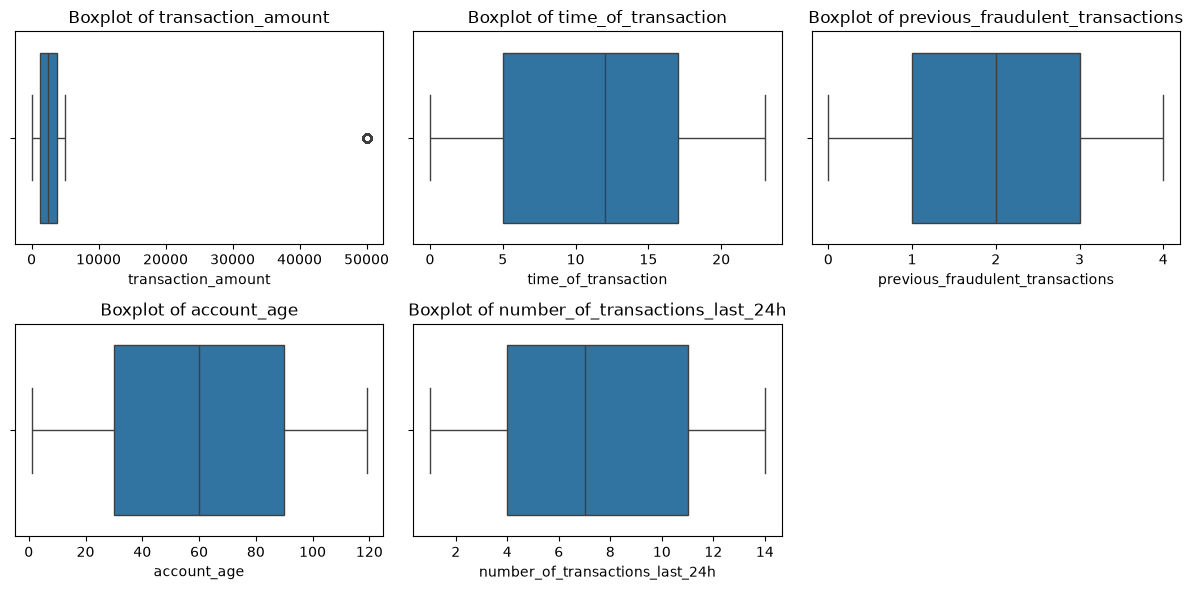

In [22]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(12, 6)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

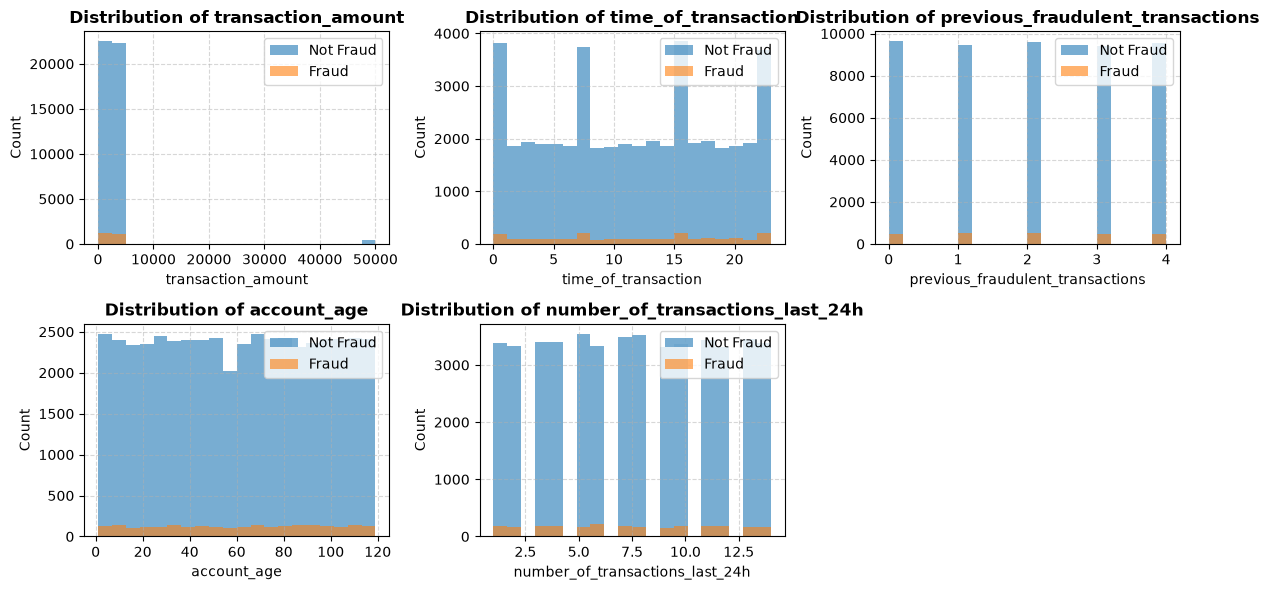

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    axes[i].hist(
        df.loc[df['fraudulent'] == 0, col],
        bins=20,
        alpha=0.6,
        label='Not Fraud'
    )

    axes[i].hist(
        df.loc[df['fraudulent'] == 1, col],
        bins=20,
        alpha=0.6,
        label='Fraud'
    )

    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

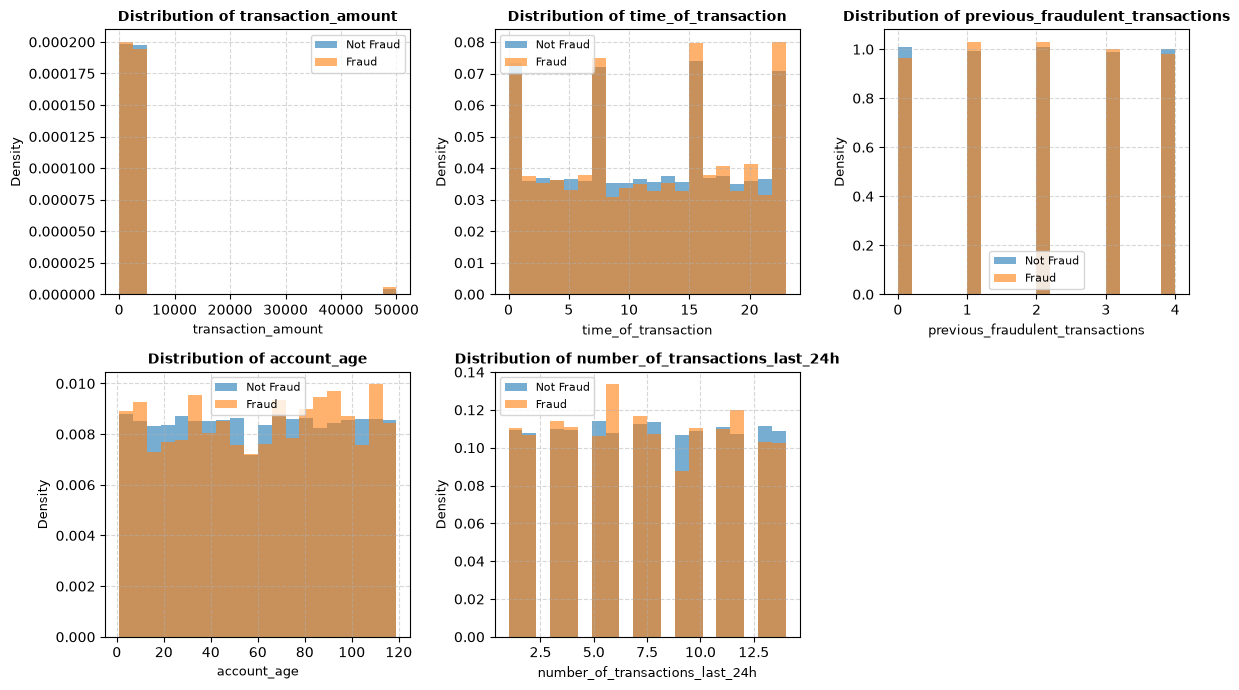

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    axes[i].hist(
        df.loc[df['fraudulent'] == 0, col],
        bins=20,
        density=True,
        alpha=0.6,
        label='Not Fraud'
    )

    axes[i].hist(
        df.loc[df['fraudulent'] == 1, col],
        bins=20,
        density=True,
        alpha=0.6,
        label='Fraud'
    )

    axes[i].set_title(f'Distribution of {col}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.5)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

### Categorical Feature Analysis

Inspect category frequencies and compare categorical features with the fraud target. Category-level fraud rates should be interpreted cautiously when groups are small.

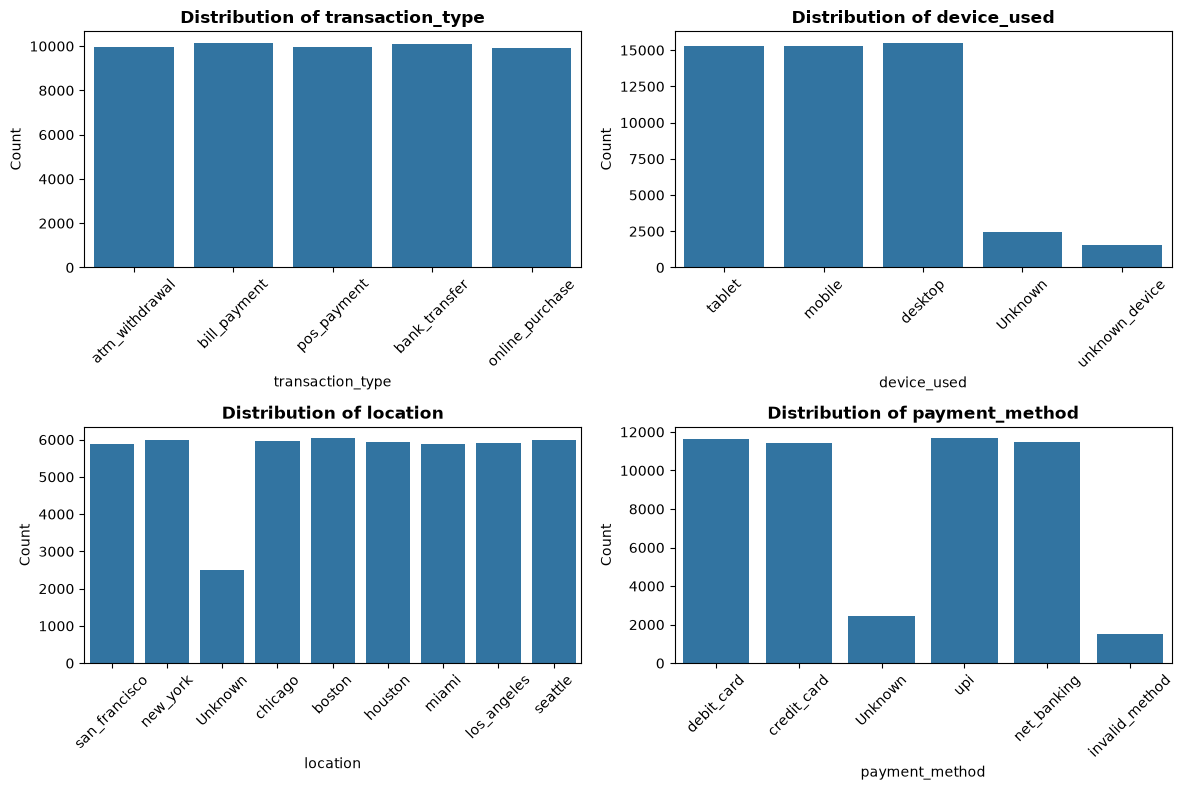

In [25]:
fig, axes = plt.subplots(
    nrows=math.ceil(len(cat_cols) / 2),
    ncols=2,
    figsize=(12, 4 * math.ceil(len(cat_cols) / 2))
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(cat_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

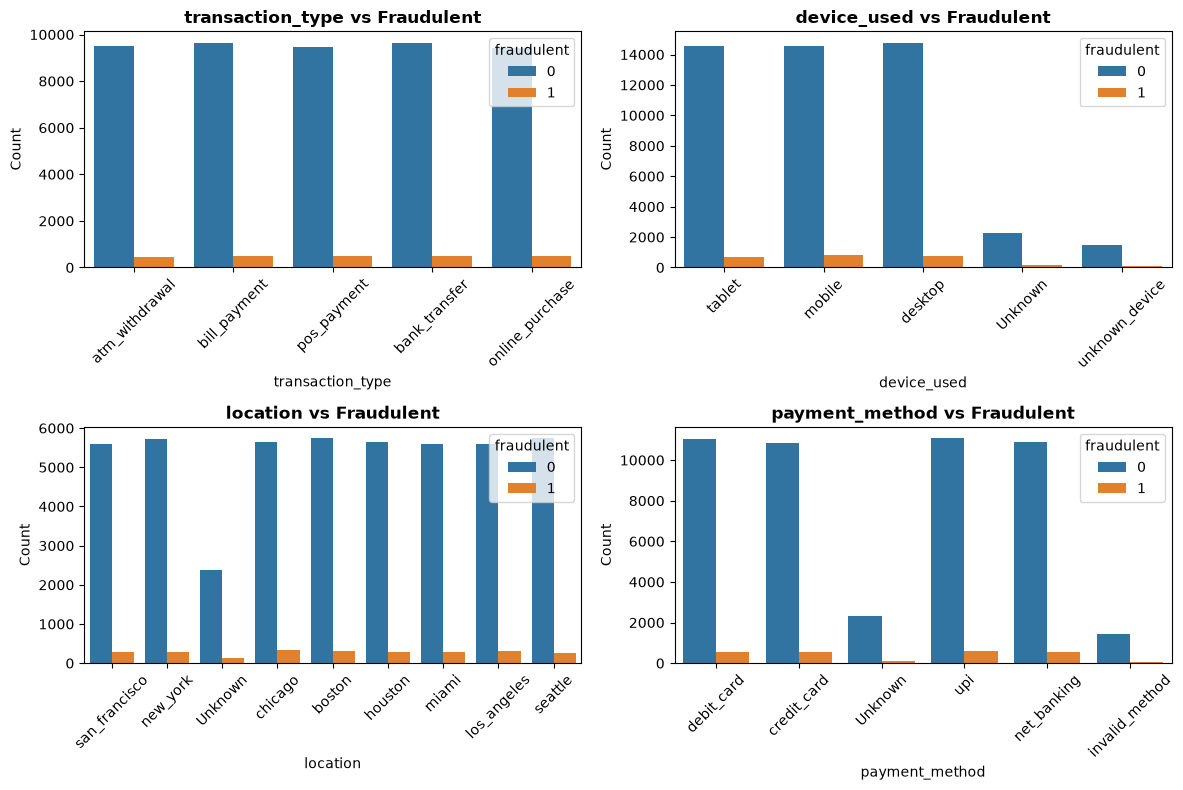

In [26]:
fig, axes = plt.subplots(
    nrows=math.ceil(len(cat_cols) / 2),
    ncols=2,
    figsize=(12, 4 * math.ceil(len(cat_cols) / 2))
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        hue='fraudulent',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Fraudulent', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(cat_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

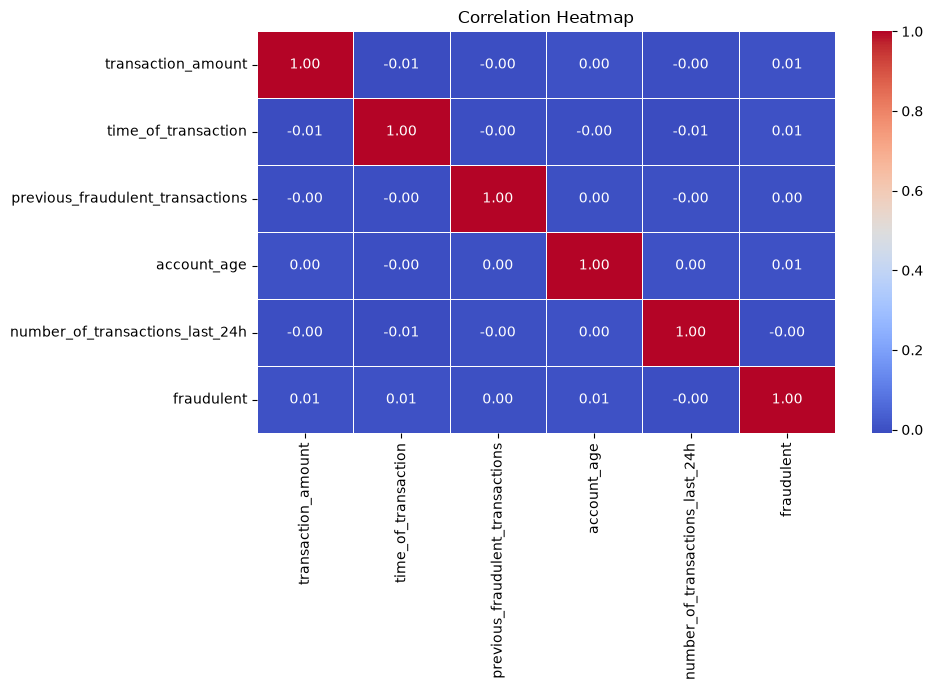

In [27]:
plt.figure(figsize=(10, 7))

corr = df[num_cols + ['fraudulent']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [28]:
df[num_cols].skew().sort_values(ascending=False)

transaction_amount                  8.429895
number_of_transactions_last_24h     0.005130
previous_fraudulent_transactions    0.003658
account_age                        -0.003052
time_of_transaction                -0.005229
dtype: float64

transaction_amount is highly right-skewed and contains extreme values. These values are plausible transaction amounts, so they should not be removed solely as statistical outliers. A log transformation can be considered during preprocessing to reduce skewness.

## Feature Engineering

Create domain-motivated indicators for previous fraud activity, new accounts, transaction frequency, account-age-adjusted activity, and nighttime transactions.

In [29]:
df["has_previous_fraud"] = (
    df["previous_fraudulent_transactions"] > 0
).astype(int)

In [30]:
df["is_new_account"] = (
    df["account_age"] < 30
).astype(int)

In [31]:
df["high_transaction_frequency"] = (
    df["number_of_transactions_last_24h"] >= 10
).astype(int)

In [32]:
df["transactions_per_account_day"] = (
    df["number_of_transactions_last_24h"] /
    (df["account_age"] + 1)
)

In [33]:
df['is_night'] = (
    (df['time_of_transaction'] < 6) |
    (df['time_of_transaction'] >= 22)
).astype(int)

In [34]:
cat_cols = df.select_dtypes(include=['object','string']).columns.to_list()
num_cols = df.select_dtypes(include=['int64','float64']).columns.to_list()
num_cols.remove('fraudulent')

## Train-Test Split and Missing-Value Handling

Use a stratified holdout split to preserve the fraud rate. Fit numerical imputation values on the training set only, then apply the same values to the test set.

In [35]:
X = df.drop(columns=['fraudulent'])
y = df['fraudulent']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)   
print('train', X_train.shape, ' test', X_test.shape)

train (40095, 14)  test (10024, 14)


In [37]:
X_train.isnull().sum()

transaction_amount                  1976
transaction_type                       0
time_of_transaction                 2001
device_used                            0
location                               0
previous_fraudulent_transactions       0
account_age                            0
number_of_transactions_last_24h        0
payment_method                         0
has_previous_fraud                     0
is_new_account                         0
high_transaction_frequency             0
transactions_per_account_day           0
is_night                               0
dtype: int64

In [38]:
X_test.isnull().sum()

transaction_amount                  500
transaction_type                      0
time_of_transaction                 504
device_used                           0
location                              0
previous_fraudulent_transactions      0
account_age                           0
number_of_transactions_last_24h       0
payment_method                        0
has_previous_fraud                    0
is_new_account                        0
high_transaction_frequency            0
transactions_per_account_day          0
is_night                              0
dtype: int64

In [39]:
null_num_cols = ['transaction_amount', 'time_of_transaction']

for col in null_num_cols:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)
    
X_test.isnull().sum()

transaction_amount                  0
transaction_type                    0
time_of_transaction                 0
device_used                         0
location                            0
previous_fraudulent_transactions    0
account_age                         0
number_of_transactions_last_24h     0
payment_method                      0
has_previous_fraud                  0
is_new_account                      0
high_transaction_frequency          0
transactions_per_account_day        0
is_night                            0
dtype: int64

## Feature Selection Diagnostics

Use mutual information, chi-square tests, and ANOVA as exploratory checks for individual feature-target relationships. These tests do not fully capture interactions, so all available features are retained for model evaluation.

### Mutual Information

In [40]:
from sklearn.feature_selection import mutual_info_classif



In [41]:
mi_X = X_train[cat_cols + num_cols].copy()

for col in cat_cols:
    mi_X[col] = mi_X[col].astype('category').cat.codes

mi_X.head(3)

,transaction_type,device_used,location,payment_method,transaction_amount,time_of_transaction,previous_fraudulent_transactions,account_age,number_of_transactions_last_24h,has_previous_fraud,is_new_account,high_transaction_frequency,transactions_per_account_day,is_night
32612,2,2,7,5,2763.27,21.0,4,38,4,1,0,0,0.102564,0
9426,3,2,8,5,989.66,20.0,2,51,9,1,0,0,0.173077,0
28171,2,1,1,5,4813.30,14.0,2,115,5,1,0,0,0.043103,0


In [42]:
discrete = [col in cat_cols for col in mi_X.columns]

mi_scores = mutual_info_classif(
    mi_X,
    y_train,
    discrete_features=discrete,
    random_state=1
)

mi = pd.DataFrame({
    'feature': mi_X.columns,
    'mutual_info': mi_scores,
    'kind': ['categorical' if d else 'numeric' for d in discrete]
})

mi = mi.sort_values(
    'mutual_info',
    ascending=False
).reset_index(drop=True)

mi.round(4)

,feature,mutual_info,kind
0,has_previous_fraud,0.0082,numeric
1,high_transaction_frequency,0.0035,numeric
2,is_night,0.0029,numeric
3,previous_fraudulent_transactions,0.0017,numeric
4,is_new_account,0.0017,numeric
5,time_of_transaction,0.0015,numeric
6,account_age,0.0001,numeric
7,location,0.0001,categorical
8,device_used,0.0001,categorical
9,transaction_type,0.0001,categorical


In [43]:
X_train[num_cols].groupby(y_train).mean()

,transaction_amount,time_of_transaction,previous_fraudulent_transactions,account_age,number_of_transactions_last_24h,has_previous_fraud,is_new_account,high_transaction_frequency,transactions_per_account_day,is_night
fraudulent,,,,,,,,,,
0,2969.978245,11.512867,1.995068,60.050812,7.518769,0.798195,0.243252,0.357860,0.277915,0.316230
1,3076.316039,11.749240,1.996454,61.393110,7.374873,0.802432,0.230496,0.348024,0.280349,0.316109


### Chi-Square Tests

Measure whether categorical feature distributions differ significantly between fraudulent and legitimate transactions.

In [44]:
rows = []

for col in cat_cols:

    table = pd.crosstab(X_train[col], y_train)

    chi2, p, dof, expected = stats.chi2_contingency(table)

    rows.append({
        'feature': col,
        'chi2': chi2,
        'p_value': p,
        'dof': dof
    })

chi = pd.DataFrame(rows).sort_values(
    'chi2',
    ascending=False
).reset_index(drop=True)

chi['keep'] = chi['p_value'] < 0.05

chi.round(4)

,feature,chi2,p_value,dof,keep
0,location,10.8676,0.2093,8,False
1,device_used,8.3887,0.0783,4,False
2,transaction_type,6.0781,0.1934,4,False
3,payment_method,5.0982,0.4040,5,False


### ANOVA Tests

Compare numerical feature means across the two target classes. A weak result indicates limited individual linear separation, not proof that the feature is useless in combination with others.

In [45]:
from sklearn.feature_selection import f_classif

rows = []

for col in num_cols:

    f_score, p_value = f_classif(
        X_train[[col]],
        y_train
    )

    rows.append({
        'feature': col,
        'f_score': f_score[0],
        'p_value': p_value[0]
    })

anova = pd.DataFrame(rows).sort_values(
    'f_score',
    ascending=False
).reset_index(drop=True)

anova['keep'] = anova['p_value'] < 0.05

anova.round(4)

,feature,f_score,p_value,keep
0,account_age,2.8626,0.0907,False
1,number_of_transactions_last_24h,2.4014,0.1212,False
2,time_of_transaction,2.3067,0.1288,False
3,is_new_account,1.6617,0.1974,False
4,transaction_amount,0.8698,0.3510,False
5,high_transaction_frequency,0.7906,0.3739,False
6,has_previous_fraud,0.2093,0.6473,False
7,transactions_per_account_day,0.0344,0.8528,False
8,previous_fraudulent_transactions,0.0018,0.9662,False
9,is_night,0.0001,0.9910,False


The filter-based feature selection methods (Mutual Information, Chi-square, and ANOVA) showed weak individual associations between the predictors and the fraud target. Since the dataset contains only nine features and these methods do not account well for feature interactions, all features were retained for subsequent modeling.

The filter-based methods showed weak individual relationships with the target. However, these methods do not fully capture nonlinear relationships or interactions between features. Therefore, the features were retained for model-based evaluation.

In [46]:
import numpy as np

X_train['transaction_amount'] = np.log1p(X_train['transaction_amount'])
X_test['transaction_amount'] = np.log1p(X_test['transaction_amount'])

In [47]:
df[num_cols].skew().sort_values(ascending=False)

transaction_amount                  8.429895
transactions_per_account_day        6.016569
is_new_account                      1.196558
is_night                            0.787266
high_transaction_frequency          0.602899
number_of_transactions_last_24h     0.005130
previous_fraudulent_transactions    0.003658
account_age                        -0.003052
time_of_transaction                -0.005229
has_previous_fraud                 -1.488062
dtype: float64

In [48]:
X_train['transaction_amount'].skew()

np.float64(-1.3062984590569784)

## Encoding, Scaling, and Preprocessing

Transform skewed numerical values, one-hot encode categorical variables, align train and test columns, and standardize features for model training.

In [49]:
X_train[cat_cols].nunique()

transaction_type    5
device_used         5
location            9
payment_method      6
dtype: int64

In [50]:
X_train = pd.get_dummies(X_train, drop_first=True).astype(float)
X_test = pd.get_dummies(X_test, drop_first=True).astype(float)

# Make train and test have the same columns
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (40095, 31)
X_test shape: (10024, 31)


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:

y_train.value_counts()

fraudulent
0    38121
1     1974
Name: count, dtype: int64

## Class-Imbalance Handling with SMOTE

Apply SMOTE only to the training data so the minority class is represented during fitting while the untouched test data remains representative of deployment conditions.

In [53]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [54]:
y_train_resampled.value_counts()

fraudulent
0    38121
1    38121
Name: count, dtype: int64

## Model Training and Evaluation

Compare several classifiers using ROC-AUC, precision, recall, confusion matrices, and classification reports. Because fraud is rare, accuracy alone is not a reliable measure of usefulness.

### Logistic Regression

Fit a balanced logistic regression model and inspect how the probability threshold changes fraud recall and precision.

In [55]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1.0, solver="liblinear", max_iter=500, class_weight="balanced")

lr.fit(X_train_resampled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,500
,multi_class,'deprecated'


In [56]:
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score)


y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))

[[4950 4581]
 [ 239  254]]
              precision    recall  f1-score   support

           0       0.95      0.52      0.67      9531
           1       0.05      0.52      0.10       493

    accuracy                           0.52     10024
   macro avg       0.50      0.52      0.38     10024
weighted avg       0.91      0.52      0.64     10024

ROC-AUC: 0.5137449420413753
Accuracy: 0.519


In [57]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

for t in [0.5, 0.4, 0.3, 0.2]:

    pred = (y_prob_lr >= t).astype(int)

    print(
        f"Threshold {t}: "
        f"Accuracy {accuracy_score(y_test, pred):.3f}, "
        f"Fraud Recall {recall_score(y_test, pred):.2f}, "
        f"Fraud Precision {precision_score(y_test, pred):.2f}"
    )

Threshold 0.5: Accuracy 0.519, Fraud Recall 0.52, Fraud Precision 0.05
Threshold 0.4: Accuracy 0.083, Fraud Recall 0.97, Fraud Precision 0.05
Threshold 0.3: Accuracy 0.049, Fraud Recall 1.00, Fraud Precision 0.05
Threshold 0.2: Accuracy 0.049, Fraud Recall 1.00, Fraud Precision 0.05


Logistic Regression achieved a test ROC-AUC of approximately 0.514, indicating very limited separation between fraudulent and legitimate transactions. Tree-based models are evaluated next to test whether nonlinear relationships improve ranking performance.

### Decision Tree

Tune a decision tree inside an imbalanced-learning pipeline using cross-validated ROC-AUC, then evaluate the selected model on the untouched test set.

In [58]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [59]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [60]:
dt_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', dt)
])

In [61]:
from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print(dt_scores)
print("Mean ROC-AUC:", dt_scores.mean())

[0.50228709 0.50067807 0.50188462 0.51764498 0.49983181]
Mean ROC-AUC: 0.504465315106489


In [62]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 5, 10]
}

In [63]:
grid = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__min_samples_split': [2, 5, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [64]:
grid.best_params_

{'model__max_depth': None,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 5}

In [65]:
best_dt = grid.best_estimator_

best_dt.named_steps['model'].get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [66]:
y_pred_dt = best_dt.predict(X_test)

y_prob_dt = best_dt.predict_proba(X_test)[:,1]

In [67]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

[[9014  517]
 [ 465   28]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      9531
           1       0.05      0.06      0.05       493

    accuracy                           0.90     10024
   macro avg       0.50      0.50      0.50     10024
weighted avg       0.91      0.90      0.90     10024

ROC-AUC: 0.4987141351281811


The tuned Decision Tree achieved a test ROC-AUC of approximately 0.499, which is equivalent to chance-level ranking. Its accuracy should not be interpreted as strong fraud detection because the fraudulent class is rare; recall, precision, ROC-AUC, and PR-AUC are more informative.

### Random Forest

Tune a Random Forest with cross-validated ROC-AUC and evaluate its probability rankings on the untouched test set.

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

In [69]:
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', rf)
])

In [70]:
rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print(rf_scores)
print("Mean ROC-AUC:", rf_scores.mean())

[0.50521461 0.50484081 0.49184155 0.51805391 0.49261891]
Mean ROC-AUC: 0.5025139600229342


In [71]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [1, 5, 10]
}

In [72]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [73]:
print(rf_grid.best_params_)

{'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [74]:
print(rf_grid.best_score_)

0.5051392008803164


In [75]:
best_rf = rf_grid.best_estimator_

In [76]:
y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [77]:
print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

[[9518   13]
 [ 492    1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9531
           1       0.07      0.00      0.00       493

    accuracy                           0.95     10024
   macro avg       0.51      0.50      0.49     10024
weighted avg       0.91      0.95      0.93     10024

ROC-AUC: 0.5001397170288562


In [82]:
from sklearn.metrics import roc_auc_score

for col in num_cols:
    temp = df[["fraudulent", col]].dropna()

    auc = roc_auc_score(
        temp["fraudulent"],
        temp[col]
    )

    useful_auc = max(auc, 1 - auc)

    print(f"{col:40s} AUC = {auc:.4f} | useful = {useful_auc:.4f}")

transaction_amount                       AUC = 0.4978 | useful = 0.5022
time_of_transaction                      AUC = 0.5078 | useful = 0.5078
previous_fraudulent_transactions         AUC = 0.5010 | useful = 0.5010
account_age                              AUC = 0.5074 | useful = 0.5074
number_of_transactions_last_24h          AUC = 0.4947 | useful = 0.5053
has_previous_fraud                       AUC = 0.5047 | useful = 0.5047
is_new_account                           AUC = 0.4950 | useful = 0.5050
high_transaction_frequency               AUC = 0.4993 | useful = 0.5007
transactions_per_account_day             AUC = 0.4931 | useful = 0.5069
is_night                                 AUC = 0.5007 | useful = 0.5007


Fraud prevalence baseline for PR-AUC: 0.0492


,model,roc_auc,pr_auc
0,Logistic Regression,0.5137,0.0502
2,Random Forest,0.5001,0.0513
1,Decision Tree,0.4987,0.0494


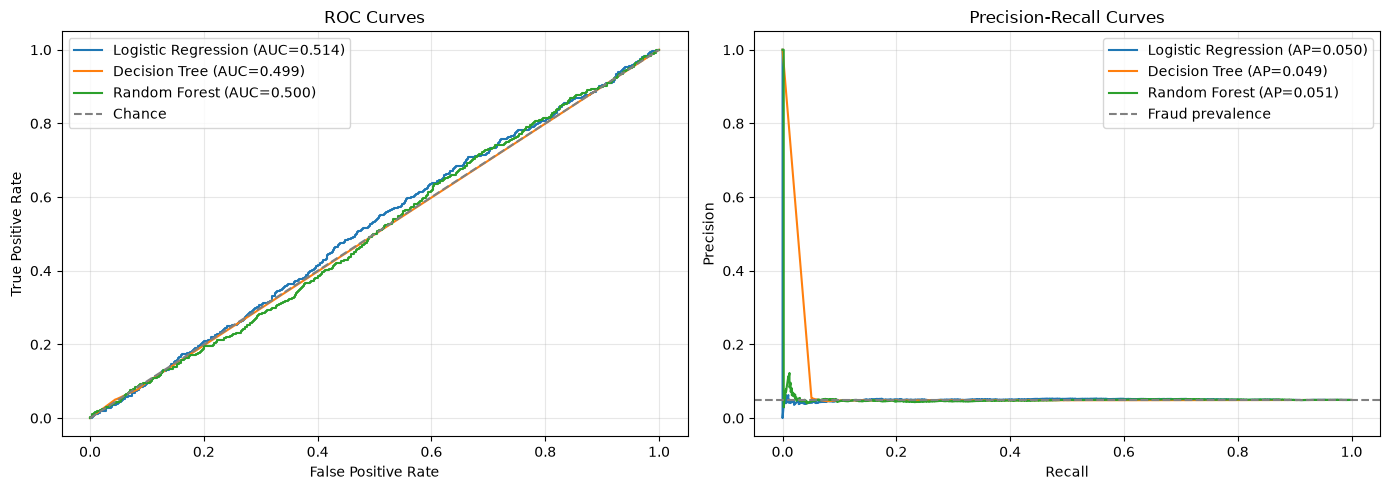

In [ ]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

model_probabilities = {
    'Logistic Regression': y_prob_lr,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf,
}

results = pd.DataFrame([
    {
        'model': name,
        'roc_auc': roc_auc_score(y_test, probabilities),
        'pr_auc': average_precision_score(y_test, probabilities),
    }
    for name, probabilities in model_probabilities.items()
]).sort_values('roc_auc', ascending=False)

print('Fraud prevalence baseline for PR-AUC:', round(y_test.mean(), 4))
display(results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    roc_value = roc_auc_score(y_test, probabilities)
    pr_value = average_precision_score(y_test, probabilities)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_value:.3f})')
    axes[1].plot(recall, precision, label=f'{name} (AP={pr_value:.3f})')

axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Chance')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Fraud prevalence')
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()      

## Model Comparison and Final Results

ROC-AUC measures how well a model ranks fraudulent transactions above legitimate ones. PR-AUC is also reported because it focuses on the minority fraud class; its baseline equals the fraud prevalence in the test set.

If ROC-AUC values remain close to 0.50 and PR-AUC remains close to the prevalence baseline, the current features do not provide enough predictive signal for reliable fraud detection. The next improvement should be better domain features, such as transaction velocity, user history, device changes, merchant behavior, and geographic consistency.

## Limitations and Reproducibility

The current workflow uses SMOTE after one-hot encoding, which can create synthetic fractional category values. `SMOTENC` or class-weighted models should be compared in a future iteration. Preprocessing should also be moved into a single cross-validation pipeline to prevent leakage and make model selection fully reproducible.